In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## 形态学-腐蚀
- 一般是对二值的黑白图像进行腐蚀,用于腐蚀清除细小的纹理

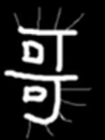

- 算法原理

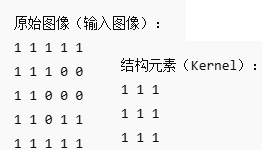

- 腐蚀操作的步骤

    - **腐蚀操作**: 会遍历输入图像中的每一个像素，使用结构元素对其周围的 3x3 邻域进行比较。对于每一个像素位置，我们检查该邻域是否完全匹配结构元素（即该邻域中的每个像素值都大于或等于结构元素对应位置的值）。

    - **判断条件**：只有当结构元素覆盖的所有像素都为 1 时，中心像素才会保持不变。如果有任何一个位置的像素不为 1，那么该像素就会被替换为 0（图像中的最小值）。

(<Axes: title={'center': 'text'}>,
 Text(0.5, 1.0, 'text'))

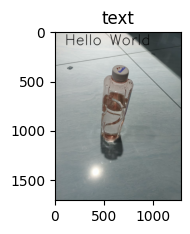

In [8]:
img = cv2.imread('./assets/1.jpg')

# 设置文本内容、位置、字体、大小、颜色和粗细
text = "Hello World"
position = (100, 130)  # 左上角位置，注意Y值稍微往下移，避免文字和边缘重叠
font = cv2.FONT_HERSHEY_SIMPLEX  # 字体类型
font_scale = 5  # 字体大小
color = (0, 0, 0)  # 黑色文字
thickness = 6  # 文字粗细

# 在图像上添加文本
cv2.putText(img, text, position, font, font_scale, color, thickness)

plt.subplot(231), plt.imshow(img), plt.title("text")

(<Axes: title={'center': 'erosion'}>,
 Text(0.5, 1.0, 'erosion'),
 (-0.5, 1278.5, 1705.5, -0.5))

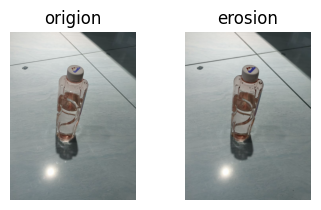

In [2]:
img = cv2.imread('./assets/1.jpg')

kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(img, kernel, iterations = 1)

plt.subplot(231), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(232), plt.imshow(erosion), plt.title("erosion"), plt.axis('off')

(<Axes: title={'center': 'erosion_3'}>,
 Text(0.5, 1.0, 'erosion_3'),
 (-0.5, 1278.5, 1705.5, -0.5))

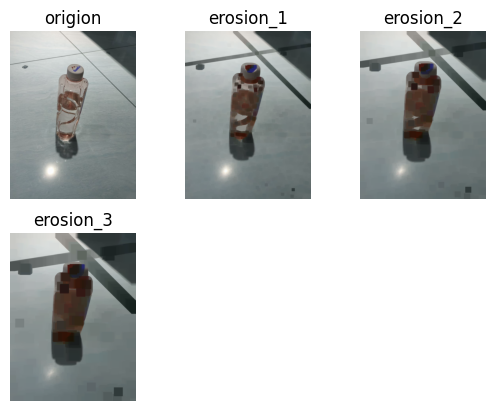

In [9]:
img = cv2.imread('./assets/1.jpg')

kernel = np.ones((30, 30), np.uint8)
erosion_1 = cv2.erode(img, kernel, iterations = 1)
erosion_2 = cv2.erode(img, kernel, iterations = 2)
erosion_3 = cv2.erode(img, kernel, iterations = 3)

plt.subplot(231), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(232), plt.imshow(erosion_1), plt.title("erosion_1"), plt.axis('off')
plt.subplot(233), plt.imshow(erosion_2), plt.title("erosion_2"), plt.axis('off')
plt.subplot(234), plt.imshow(erosion_3), plt.title("erosion_3"), plt.axis('off')

### 膨胀操作

(<Axes: title={'center': 'e_d'}>,
 Text(0.5, 1.0, 'e_d'),
 (-0.5, 1278.5, 1705.5, -0.5))

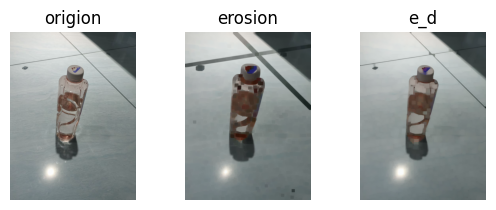

In [14]:
img = cv2.imread('./assets/1.jpg')

kernel = np.ones((30, 30), np.uint8)
erosion = cv2.erode(img, kernel, iterations = 1)

kernel_dilate = np.ones((30, 30), np.uint8)
erosion_dilate = cv2.dilate(erosion, kernel_dilate, iterations = 1)

plt.subplot(231), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(232), plt.imshow(erosion), plt.title("erosion"), plt.axis('off')
plt.subplot(233), plt.imshow(erosion_dilate), plt.title("e_d"), plt.axis('off')

### 开运算和闭运算

(<Axes: title={'center': 'closing'}>,
 Text(0.5, 1.0, 'closing'),
 (-0.5, 1278.5, 1705.5, -0.5))

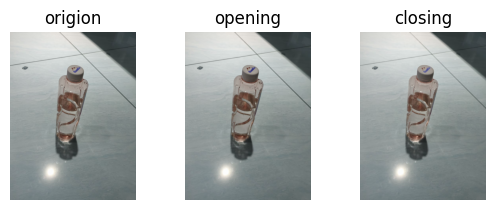

In [15]:
img = cv2.imread('./assets/1.jpg')

# 先腐蚀，再膨胀 = 开运算
kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

plt.subplot(231), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(232), plt.imshow(opening), plt.title("opening"), plt.axis('off')
plt.subplot(233), plt.imshow(closing), plt.title("closing"), plt.axis('off')

### 梯度运算
- 想得到边界 轮廓 信息
- 梯度 = 膨胀 - 腐蚀

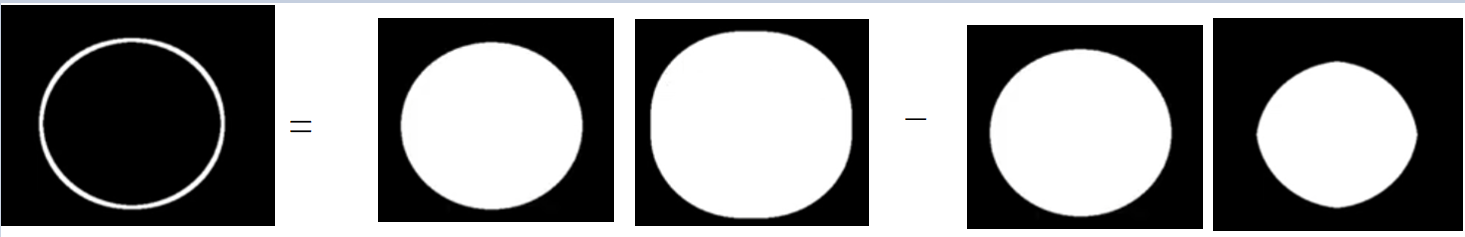

(<Axes: title={'center': 'gradient'}>,
 Text(0.5, 1.0, 'gradient'),
 (-0.5, 1278.5, 1705.5, -0.5))

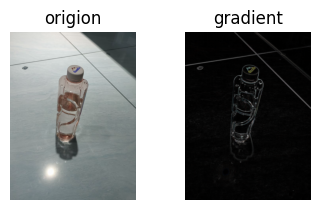

In [16]:
img = cv2.imread('./assets/1.jpg')

kernel = np.ones((5, 5), np.uint8)
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

plt.subplot(231), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(232), plt.imshow(gradient), plt.title("gradient"), plt.axis('off')

### 礼帽与黑帽
- 礼帽 = 原始图像 - 开运算（只剩下纹理细节）
- 黑帽 = 闭运算 - 原始图像（增强的纹理细节）

(<Axes: title={'center': 'blackhat2'}>,
 Text(0.5, 1.0, 'blackhat2'),
 (-0.5, 1278.5, 1705.5, -0.5))

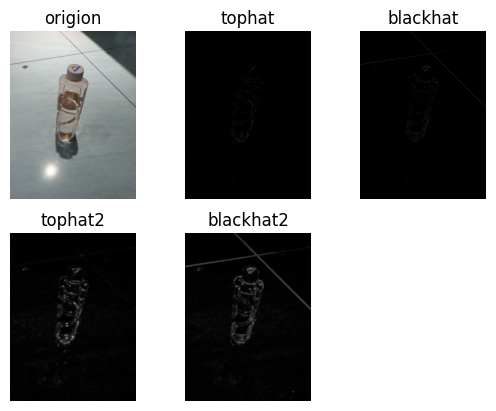

In [4]:
img = cv2.imread('./assets/1.jpg')

kernel = np.ones((5, 5), np.uint8)
tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

tophat_dilate = cv2.dilate(tophat, kernel, iterations = 3)
blackhat_dilate = cv2.dilate(blackhat, kernel, iterations = 3)

plt.subplot(231), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(232), plt.imshow(tophat), plt.title("tophat"), plt.axis('off')
plt.subplot(233), plt.imshow(blackhat), plt.title("blackhat"), plt.axis('off')
plt.subplot(234), plt.imshow(tophat_dilate), plt.title("tophat2"), plt.axis('off')
plt.subplot(235), plt.imshow(blackhat_dilate), plt.title("blackhat2"), plt.axis('off')